## **Preprocessing and K-Means Clustering**

----
----

#### **Importing Dependencies and libraries**

In [62]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import warnings 
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from matplotlib import cm
from sklearn.decomposition import PCA  
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator

warnings.filterwarnings('ignore')
!pip install kneed

In [63]:
path = "data/*.csv"   
files = glob.glob(path)

df_list = []

for file in files:
    temp = pd.read_csv(file)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print("Total rows:", len(df))
print(df.head())

Total rows: 1578240
  datetime_beginning_utc datetime_beginning_ept nerc_region mkt_region zone  \
0    2/1/2024 5:00:00 AM   2/1/2024 12:00:00 AM         RFC     MIDATL   AE   
1    2/1/2024 5:00:00 AM   2/1/2024 12:00:00 AM         RFC       WEST  AEP   
2    2/1/2024 5:00:00 AM   2/1/2024 12:00:00 AM         RFC       WEST  AEP   
3    2/1/2024 5:00:00 AM   2/1/2024 12:00:00 AM         RFC       WEST  AEP   
4    2/1/2024 5:00:00 AM   2/1/2024 12:00:00 AM         RFC       WEST  AEP   

  load_area        mw  is_verified  
0      AECO   933.150         True  
1    AEPAPT  4587.152         True  
2    AEPIMP  3103.502         True  
3    AEPKPT   699.649         True  
4    AEPOPT  5028.151         True  


In [64]:
df['datetime_beginning_utc'] = pd.to_datetime(df['datetime_beginning_utc'])

In [65]:
df = df.sort_values('datetime_beginning_utc')

In [66]:
df = df.drop_duplicates()

In [67]:
df_old = df.copy()

---

## Feature Engineering 

Feature engineering refers to manipulation - addition, deletion, combination, mutation of our data set to improve machine learning model training, leading to better performance and greater accuracy.

---

#### Feature Extraction

* We will extract and create some of the meaningful features.

**We'll repeat some steps from EDA**

**The following code creates features that would be helpful to describe the profile of the customer.**

In [68]:
df['date'] = df['datetime_beginning_utc'].dt.date
df['year'] = df['datetime_beginning_utc'].dt.year
df['month'] = df['datetime_beginning_utc'].dt.month
df['day'] = df['datetime_beginning_utc'].dt.day
df['hour'] = df['datetime_beginning_utc'].dt.hour
df['weekday'] = df['datetime_beginning_utc'].dt.weekday
df['day_type'] = df['weekday'].apply(lambda x: 'Weekend' if x >=5 else 'Weekday')

In [69]:
daily = df.groupby(['zone','date']).agg(
    total_energy=('mw','sum'),
    peak_load=('mw','max'),
    avg_load=('mw','mean'),
    min_load=('mw','min')
).reset_index()

In [70]:
daily

,zone,date,total_energy,peak_load,avg_load,min_load
0,AE,2020-02-01,18895.503,1090.572,497.250079,60.255
1,AE,2020-02-02,23937.270,1125.985,498.693125,50.009
2,AE,2020-02-03,23289.581,1100.489,485.199604,55.602
3,AE,2020-02-04,23833.218,1096.465,496.525375,60.844
4,AE,2020-02-05,24308.232,1158.962,506.421500,58.605
...,...,...,...,...,...,...
48241,RTO,2026-01-28,3034632.815,136576.653,126443.033958,117678.914
48242,RTO,2026-01-29,3075468.853,139048.020,128144.535542,121245.546
48243,RTO,2026-01-30,3090994.946,138480.691,128791.456083,121479.245
48244,RTO,2026-01-31,3074495.470,134248.278,128103.977917,122827.946


In [71]:
daily['load_factor'] = daily['avg_load'] / daily['peak_load']

daily['utilization_rate'] = (
    daily['peak_load'] /
    daily.groupby('zone')['peak_load'].transform('max')
)

daily['range'] = daily['peak_load'] - daily['min_load']

daily['cv'] = (
    daily.groupby('zone')['total_energy'].transform('std') /
    daily.groupby('zone')['total_energy'].transform('mean')
)

In [72]:
daily

,zone,date,total_energy,peak_load,avg_load,min_load,load_factor,utilization_rate,range,cv
0,AE,2020-02-01,18895.503,1090.572,497.250079,60.255,0.455953,0.427770,1030.317,0.242880
1,AE,2020-02-02,23937.270,1125.985,498.693125,50.009,0.442895,0.441661,1075.976,0.242880
2,AE,2020-02-03,23289.581,1100.489,485.199604,55.602,0.440895,0.431660,1044.887,0.242880
3,AE,2020-02-04,23833.218,1096.465,496.525375,60.844,0.452842,0.430082,1035.621,0.242880
4,AE,2020-02-05,24308.232,1158.962,506.421500,58.605,0.436961,0.454596,1100.357,0.242880
...,...,...,...,...,...,...,...,...,...,...
48241,RTO,2026-01-28,3034632.815,136576.653,126443.033958,117678.914,0.925803,0.852781,18897.739,0.141149
48242,RTO,2026-01-29,3075468.853,139048.020,128144.535542,121245.546,0.921585,0.868212,17802.474,0.141149
48243,RTO,2026-01-30,3090994.946,138480.691,128791.456083,121479.245,0.930032,0.864670,17001.446,0.141149
48244,RTO,2026-01-31,3074495.470,134248.278,128103.977917,122827.946,0.954232,0.838243,11420.332,0.141149


In [73]:
transformer_features = daily.groupby('zone').agg({
    'total_energy': 'mean',      # average daily energy
    'peak_load': 'mean',         # average daily peak
    'avg_load': 'mean',          # average load
    'load_factor': 'mean',       # average efficiency
    'range': 'mean',             # avg daily variation
}).reset_index()

transformer_features

,zone,total_energy,peak_load,avg_load,load_factor,range
0,AE,2.702048e+04,1345.003793,563.230114,0.422971,1281.087578
1,AEP,3.552039e+05,7681.410973,3702.373842,0.485814,7134.248473
2,AP,1.339912e+05,6445.359307,5586.492955,0.869573,1707.045111
3,ATSI,1.808215e+05,7985.183487,3769.107496,0.474672,7529.823148
4,BC,8.367460e+04,4197.929761,3488.705137,0.835991,1360.664982
5,CE,2.572276e+05,12524.535419,10723.237930,0.863857,3636.395534
6,DAY,4.721995e+04,2290.095944,1968.591748,0.864065,667.910800
7,DEOK,7.182934e+04,3500.705075,2994.614661,0.861512,1039.965771
8,DOM,3.190139e+05,15526.363338,13301.796705,0.859979,4295.380541
9,DPL,5.084664e+04,2547.384533,1060.034159,0.418844,2524.779823


In [74]:
cv = daily.groupby('zone')['total_energy'].std() / \
     daily.groupby('zone')['total_energy'].mean()

transformer_features['cv'] = transformer_features['zone'].map(cv)

In [75]:
transformer_features['peak_to_avg_ratio'] = \
    transformer_features['peak_load'] / transformer_features['avg_load']

In [76]:
max_peak = daily.groupby('zone')['peak_load'].max()
transformer_features['max_peak'] = transformer_features['zone'].map(max_peak)

---

#### Checking how many values are higher than average load.


Here we are not capping any outliers since it's a time series data. If our data would have been some other data like customer_categorizer then we would have done it.

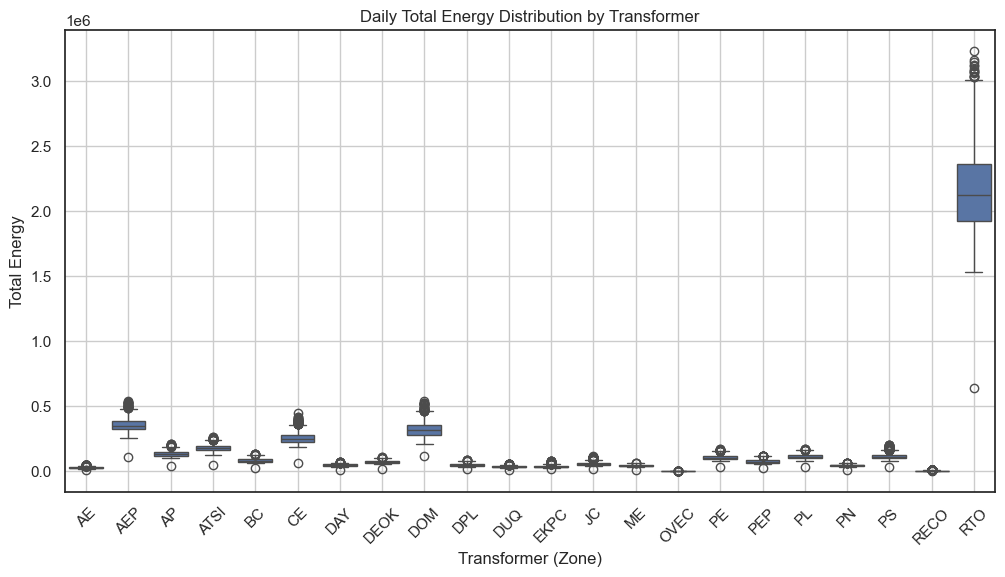

In [77]:
plt.figure(figsize=(12,6))
sns.boxplot(x='zone', y='total_energy', data=daily)

plt.xticks(rotation=45)
plt.title("Daily Total Energy Distribution by Transformer")
plt.ylabel("Total Energy")
plt.xlabel("Transformer (Zone)")
plt.grid(True)
plt.show()

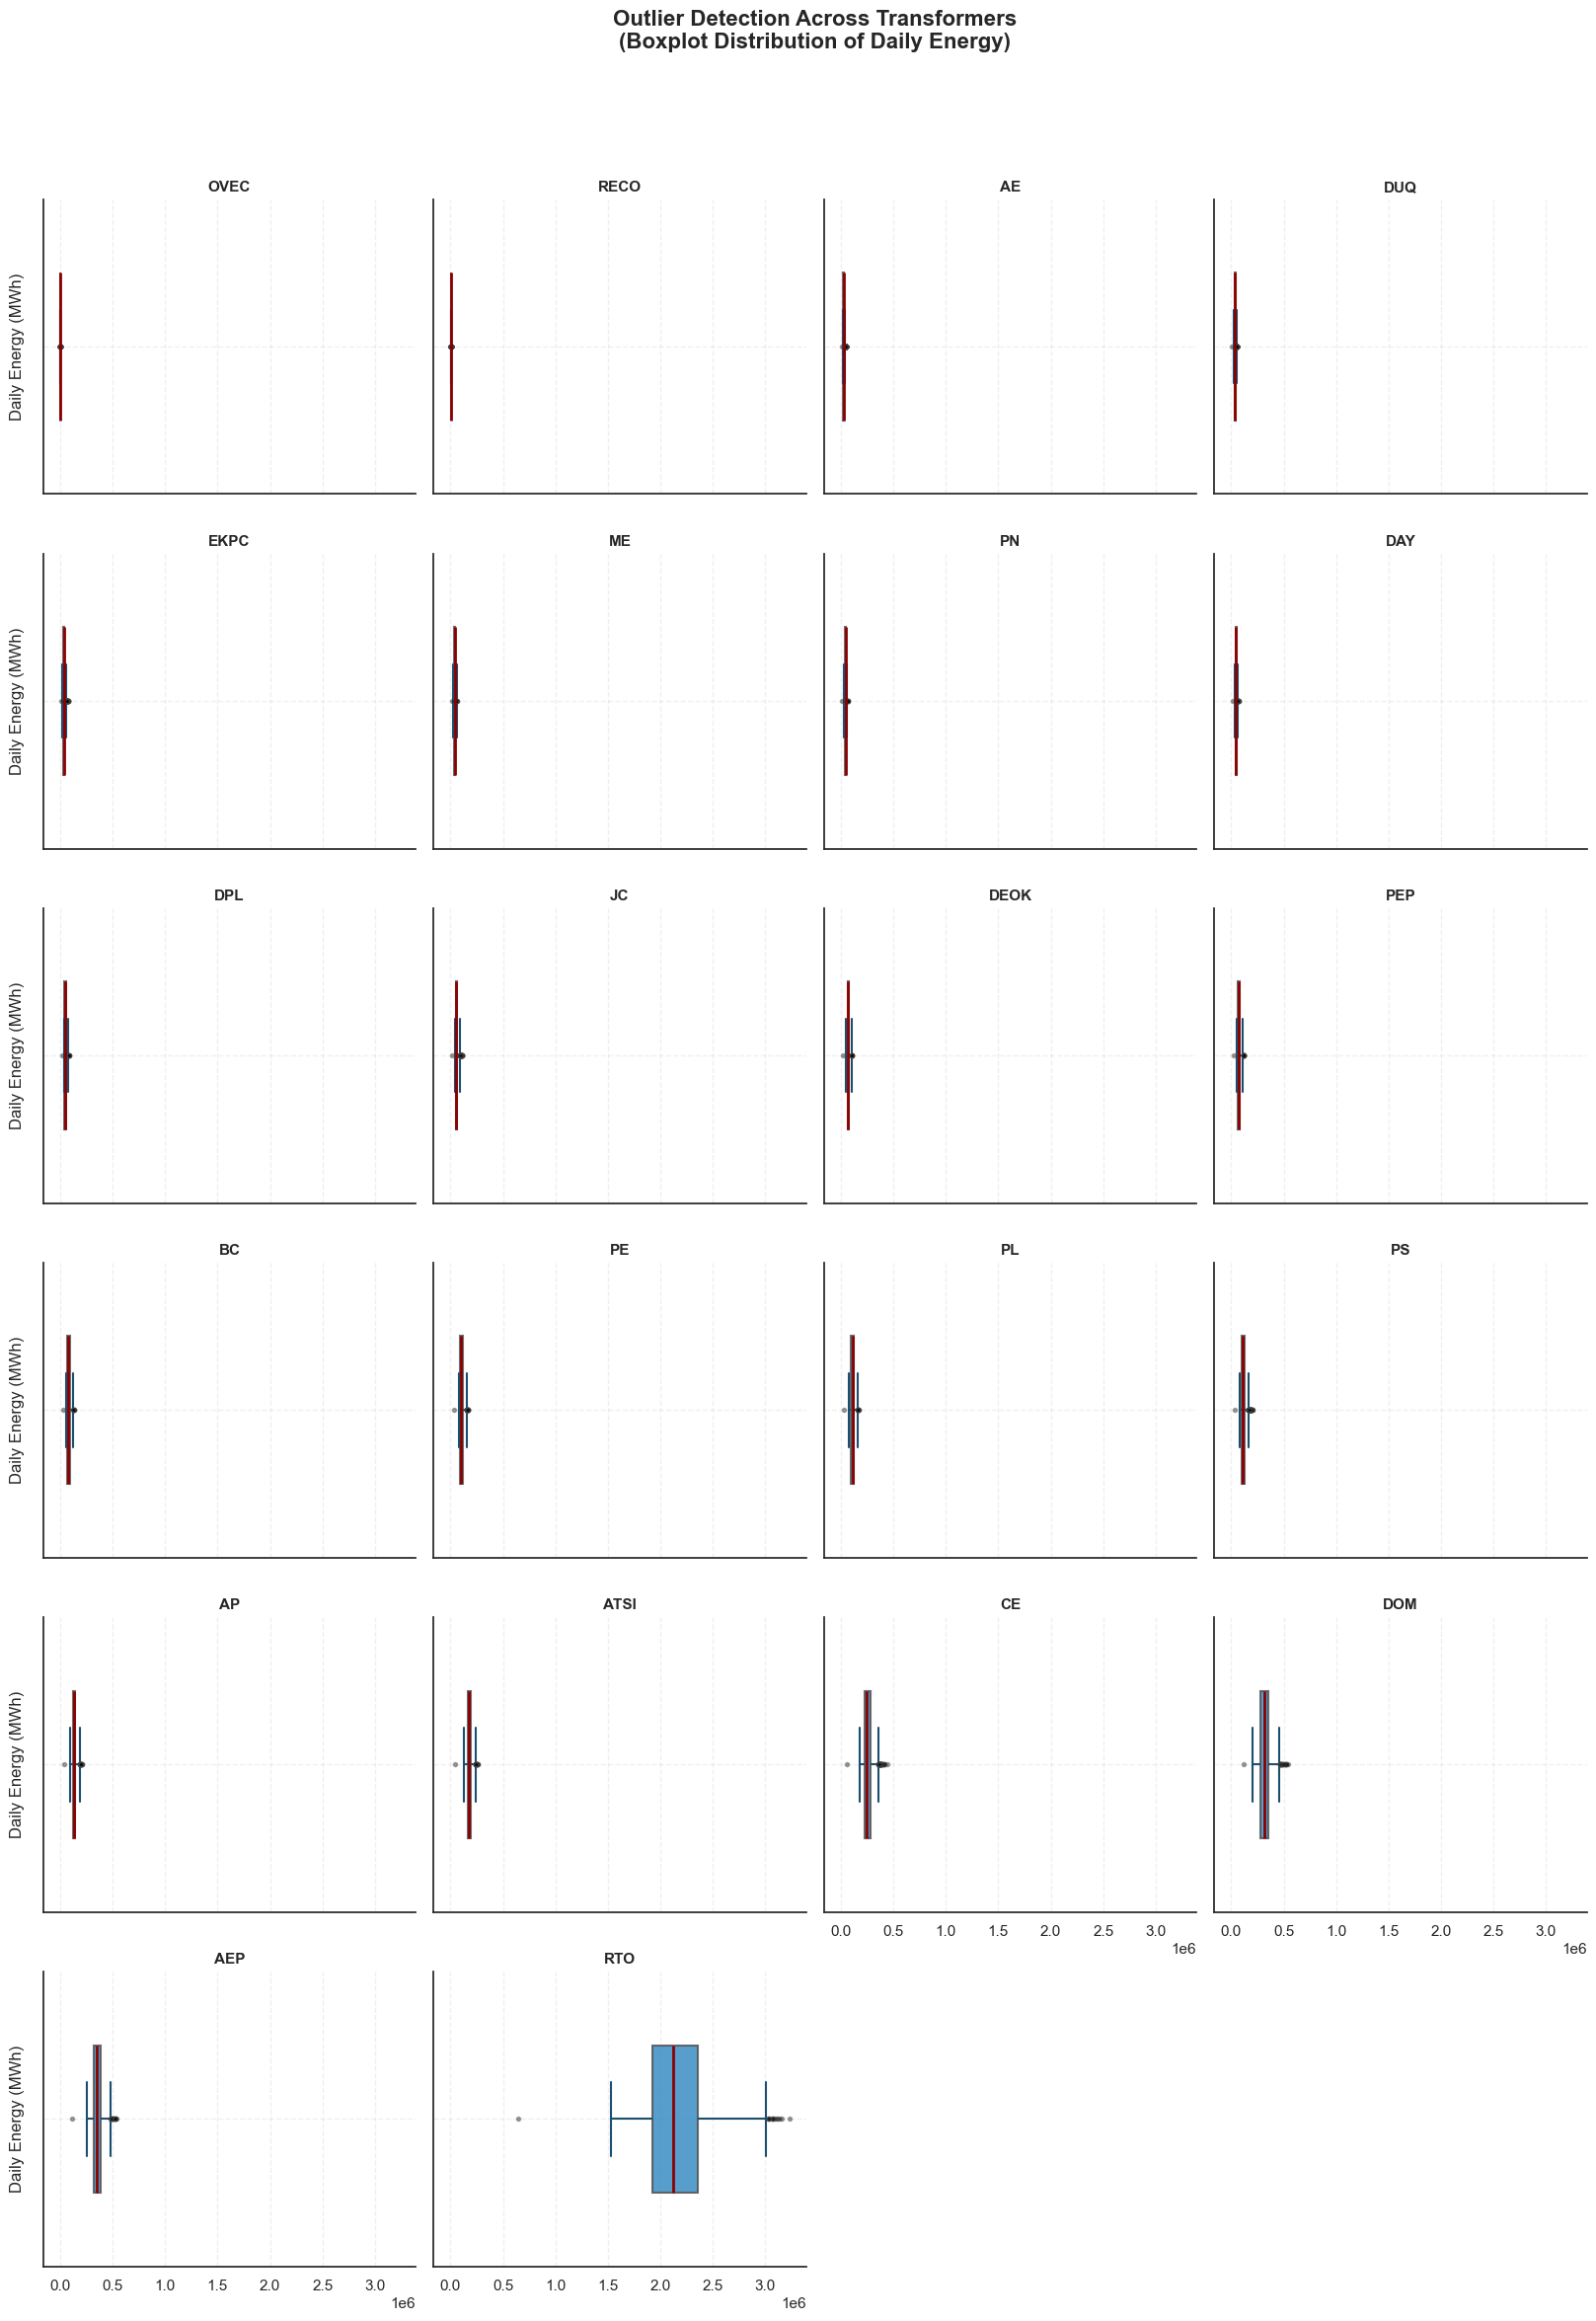

In [78]:
# Clean white professional style
plt.style.use("default")
sns.set_theme(style="white")

# Optional: sort zones by median load (makes it analytical)
zone_order = (
    daily.groupby("zone")["total_energy"]
    .median()
    .sort_values()
    .index
)

# Create FacetGrid
g = sns.FacetGrid(
    daily,
    col="zone",
    col_wrap=4,
    height=4,
    sharey=True,
    col_order=zone_order
)

# Map enhanced boxplot
g.map(
    sns.boxplot,
    "total_energy",
    width=0.5,
    boxprops=dict(facecolor="#2E86C1", alpha=0.8, linewidth=1.5),
    whiskerprops=dict(color="#1B4F72", linewidth=1.5),
    capprops=dict(color="#1B4F72", linewidth=1.5),
    medianprops=dict(color="darkred", linewidth=2),
    flierprops=dict(marker='o', markersize=3, markerfacecolor='black', alpha=0.4)
)

# Remove x-label repetition
g.set_axis_labels("", "Daily Energy (MWh)")

# Remove individual titles styling
for ax in g.axes.flatten():
    ax.set_title(ax.get_title().replace("zone = ", ""), 
                 fontsize=11, 
                 fontweight='bold')
    ax.grid(True, linestyle="--", alpha=0.3)

# Global title
plt.subplots_adjust(top=0.90)
g.fig.suptitle(
    "Outlier Detection Across Transformers\n(Boxplot Distribution of Daily Energy)",
    fontsize=16,
    fontweight="bold"
)

plt.show()

**Report**

* We can see that there are very few outliers in terms of energy. Most of the transformers are in consistent state.


---

In [79]:
continuous_features = daily.drop(['zone','date'],axis=1).columns

**Checking Skewness after outlier capping**

In [80]:
daily[continuous_features].skew(axis=0)

total_energy        4.205726
peak_load           4.358969
avg_load            4.318665
min_load            4.300692
load_factor        -0.841065
utilization_rate    0.080430
range               4.920950
cv                  0.673219
dtype: float64

---
# Feature Transformation

---

#### Scaling

* **What is Feature Scaling** 
    * Feature scaling is a method used to normalize the range of independent variables or features of data. In data processing, it is also known as data normalization and is generally performed during the data preprocessing step.

* **Why we use feature scaling**
    * The feature scaling was implemented to prevent any skewness in the contour plot of the cost function which affects the gradient descent but the analytical solution using normal equation does not suffer from the same drawback. 

* **Why using Robust Scaler?**

Since our dataset showed skewness so StandardScaler will not be a good option here, that's why we are implementing a RobustScaler.

* RobustScaler: The Robust scaler works by subtracting the data with the median followed by division with the interquartile range.

X_scaled = X - Median(X) / (Q3 - Q1)

In [81]:
X = transformer_features.drop('zone', axis=1)

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

In [82]:
X_scaled

array([[-5.46698445e-01, -4.88186621e-01, -6.96071719e-01,
        -1.36592768e+00, -7.34664672e-02,  1.56421619e+00,
         1.67900332e+00, -4.65530254e-01],
       [ 3.26124637e+00,  1.02109852e+00,  4.77319247e-01,
        -1.15892336e+00,  2.01330851e+00, -6.76228460e-01,
         1.23582307e+00,  8.86372889e-01],
       [ 6.94493556e-01,  7.26680190e-01,  1.18159039e+00,
         1.05180098e-01,  7.83963533e-02, -4.55611375e-01,
        -6.69948190e-02,  5.73925694e-01],
       [ 1.23787061e+00,  1.09345488e+00,  5.02263841e-01,
        -1.19562476e+00,  2.15433920e+00, -7.52440691e-01,
         1.29786903e+00,  8.73201602e-01],
       [ 1.10665110e-01,  1.91359160e-01,  3.97451311e-01,
        -5.43753287e-03, -4.50954486e-02,  2.52485387e-01,
         3.10072950e-03,  1.39654139e-01],
       [ 2.12441838e+00,  2.17469480e+00,  3.10167136e+00,
         8.63533671e-02,  7.66250363e-01, -1.24923114e-01,
        -4.68497301e-02,  2.39320142e+00],
       [-3.12321960e-01, -2.630726

In [83]:
X_behavior = transformer_features[['load_factor', 'cv', 'range', 'peak_to_avg_ratio']]

In [84]:
scaler = RobustScaler()
X_scaled_behavior = scaler.fit_transform(X_behavior)

---

#### Model Building (Clustering)

We know that our dataset is unsupervised, that means we don't have such target column.So we will be using clustering algorithms first to cluster the dataset and create target levels out of it.

* What is clustering?

Using a clustering algorithm means we're going to give the algorithm a lot of input data with no labels and let it find any groupings in the data it can. Those groupings are called clusters. A cluster is a group of data points that are similar to each other based on their relation to the sorrounding data points. 

Here for the Clustering Problem statement, 4 algorithms are used. 

* K Means Clustering 
* Agglomerative Clustering 
* Gaussian Mixture 
* DBSCAN

---

#### Creating a function for silhouette score plot 


* **What is silhouette score**

The silhouette value is a measure of how similar an object is to its own cluster (cohesion) compared to other clusters(separation). The silhouette ranges from -1 to +1 where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.

In [85]:
def silhouette_plot(model, range_n_clusters,X_clustering,pca, **kwags):
    for n_clusters in range_n_clusters: 
        # create a subplot with 1 row and 2 columns 
        fig, (ax1, ax2) = plt.subplots(1, 2) 
        fig.set_size_inches(18, 7) 

        # The 1st subplot is silhouette plot 
        # The silhouette coeffecient can range from -1 , +1  but in this example all 
        ax1.set_xlim([-0.1, 1])
        # The [n_clusters + 1]*10 is for inserting blank space between silhouette 
        # pots of individual clusters, to decorate them clearly.  
        ax1.set_ylim([0, len(X_clustering) + (n_clusters + 1) * 10]) 

        # Initialize the cluster with n_clusters value and a random generator 
        # seed of 10 for reproducibility
        clusterer = model(n_clusters,**kwags) 
        cluster_labels = clusterer.fit_predict(X_clustering) 

        # The Silhouette_score gives the average value for all the samples. 
        # This gives a perspective into the density and seperation of the forward 
        # clusters

        silhouette_avg = silhouette_score(X_clustering, cluster_labels) 
        print("For n_clusters -", 
             n_clusters, 
             "The average silhouette_score is" , 
             silhouette_avg,
             )

        # computing the silhouette scores for each sample 
        sample_silhouette_values = silhouette_samples(X_clustering, cluster_labels )

        y_lower = 10 
        for i in range(n_clusters): 
            # Aggregate the silhouette scores for sample belonging to 
            # cluster i and sort them 
            ith_cluster_silhouette_values= sample_silhouette_values[cluster_labels == i ]
            ith_cluster_silhouette_values.sort() 

            size_cluster_i = ith_cluster_silhouette_values.shape[0] 
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters) 
            ax1.fill_betweenx(
                np.arange(y_lower,y_upper), 
                0, 
                ith_cluster_silhouette_values, 
                facecolor = color, 
                edgecolor = color, 
                alpha=0.7,
            )

            # Label the silhouette plots with their cluster number at the middle
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i)) 

            # computer the y_lower for next plot 
            y_lower = y_upper + 10 # 10 for the 0 samples 

        ax1.set_title("The silhouette plot for the various clusters.") 
        ax1.set_xlabel("The silhouette coeffecient values") 
        ax1.set_ylabel("Cluster label") 

        # The vertical line for average silhouette score of all the values 
        ax1.axvline(x=silhouette_avg, color='red',linestyle='--') 

        ax1.set_yticks([]) # clearing the y axis labels ticks why? 
        ax1.set_xticks([-0.2, -0.1, 0, 0.2, 0.4, 0.6, 0.8, 1]) 

        # 2nd plot showing the actual clusters formed  colors cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)

        sns.scatterplot(
            x = pca[:, 0], 
            y = pca[:, 1], 
            hue = cluster_labels, 
            palette=sns.color_palette("colorblind", len(set(cluster_labels))), 
            alpha = 0.7, 
            legend="full", 
            ax = ax2 
            
        )

        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel("Feature space for 1st feature") 
        ax2.set_ylabel("Feature space for 2nd feature") 

        plt.suptitle(
            f"Silhoutte analysis for {model.__name__} clustering on sample with n_cluster = %d "
            %n_clusters, 
            fontsize=14, 
            fontweight = "bold", 
        )

    plt.show()

In [86]:
cluster_profile = transformer_features.copy()

---

## PCA (Principal Component Analysis)

There is many high correlation feature so we will use dimensionality reduction. We can use PCA

* Principal Component Analysis, or PCA, is a dimensionality-reduction method that is often used to reduce the dimensionality of large data sets, by transforming a large set of variables into a smaller one that still contains most of the information in the large set. 

* Reducing the number of variables of a data set naturally comes at the expense of accuracy, but the trick in dimensionality reduction is to trade a little accuracy for simplicity. Because smaller data sets are easier to explore and visualize and make analyzing data much easier and faster for machine learning algorithms without extraneous variables to process.


---

In [87]:
df_scaled = X_scaled_behavior.copy() 
var_ratio = {}
for n in range(2,4): 
    pc = PCA(n_components=n) 
    df_pca = pc.fit(df_scaled) 
    var_ratio[n] = sum(df_pca.explained_variance_ratio_)

#### Choosing PCA n_components and KMeans n_clusters based on Clustering metric

In [88]:
for y in range(2, 5): 
    print("PCA with # of component:", y) 
    pca = PCA(n_components=y) 
    data_p = pca.fit_transform(df_scaled) 
    for x in range(2, 7): 
        kmeans = KMeans(n_clusters=x,)
        label = kmeans.fit_predict(data_p) 
        print("Silhouette-score for ", x, "Clusters: ", silhouette_score(data_p, label), '     Inertia:', kmeans.inertia_)
    print()

PCA with # of component: 2
Silhouette-score for  2 Clusters:  0.7991463239139681      Inertia: 30.814062298813532
Silhouette-score for  3 Clusters:  0.599964177398996      Inertia: 10.569666297255267
Silhouette-score for  4 Clusters:  0.6184764942211823      Inertia: 5.6368765851995475
Silhouette-score for  5 Clusters:  0.46384219625369455      Inertia: 3.5414326414449833
Silhouette-score for  6 Clusters:  0.5543072634877038      Inertia: 1.9422901592472703

PCA with # of component: 3
Silhouette-score for  2 Clusters:  0.7702050065257652      Inertia: 40.67061028864766
Silhouette-score for  3 Clusters:  0.5021106926638187      Inertia: 19.33795606051584
Silhouette-score for  4 Clusters:  0.35400916766184964      Inertia: 14.55203743367518
Silhouette-score for  5 Clusters:  0.4129766991914099      Inertia: 7.804484681494218
Silhouette-score for  6 Clusters:  0.43638771300732837      Inertia: 5.346845125429568

PCA with # of component: 4
Silhouette-score for  2 Clusters:  0.7701086573413

**Report** 

* We can go with PCA with 2 Components 
* We can go with KMeans clusters with range 3-4 as it has good score with lesser inertia compared to others. 

---

In [89]:
# Reducing the dimensions of the data 
pca_final = PCA(n_components=2, random_state=42).fit(df_scaled) 

reduced = pca_final.fit_transform(df_scaled) 
pcadf = pd.DataFrame(reduced) 
pcadf.columns = ["PC1","PC2"]

pcadf.head(10)

,PC1,PC2
0,-0.878667,2.002632
1,1.460876,0.919726
2,-0.537727,-0.768711
3,1.612423,0.966477
4,-0.746373,-0.442615
5,0.103145,-0.639122
6,-0.915091,-0.726470
7,-0.795943,-0.684835
8,0.300400,-0.546771
9,-0.322889,1.764846


The explained variance ratio is the percentage of variance that is attributed by each of the selected components.

In [90]:
pca_final.explained_variance_ratio_

array([0.77431473, 0.14063974])

---

#### Elbow method to find best clusters for k-means

* In the Elbow method, we are actually varying the number of clusters ( K ) from 1-10. For each value of K, we are calculating WCSS(Within-cluster sum of square). WCSS is the sum of squared distance between each point and the centroid of the cluster. When we plot the WCSS with K value, the plot looks like an Elbow. As the number of clusters increases, the WCSS value will start to decrease. WCSS value is largest when K=1. When we will analyze the graph we will see that the graph will be rapidly changing at a point and thus creating an elbow shape.

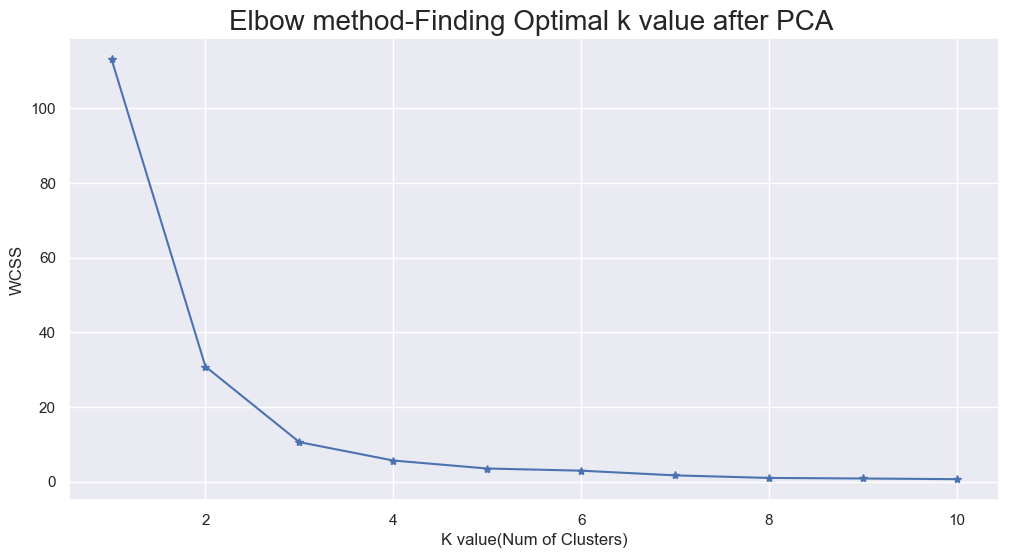

In [91]:
wcss = {}
sns.set() 
plt.figure(figsize=(12, 6)) 
for i in range(1, 11): 
    km = KMeans(n_clusters=i) 
    km.fit(pcadf) 
    wcss[i]=km.inertia_

plt.plot(range(1, 11), wcss.values(), marker = '*') 
plt.title('Elbow method-Finding Optimal k value after PCA ', fontsize =20)
plt.xlabel('K value(Num of Clusters)')
plt.ylabel('WCSS') 
plt.show()

* Here the optimum number of clusters is 3 since it is the place where the graph starts to flatten out meaning that having higher number of cluster will not yield a much more fitting machine. 

**Reports:**

* We will use **k=3**,thus there will be **three clusters** in our dataset.
* We will use **KMeans Algorithm** for clustering.

---

For n_clusters - 3 The average silhouette_score is 0.599964177398996
For n_clusters - 4 The average silhouette_score is 0.6184764942211823
For n_clusters - 5 The average silhouette_score is 0.5413928324347854
For n_clusters - 6 The average silhouette_score is 0.5062194359696286


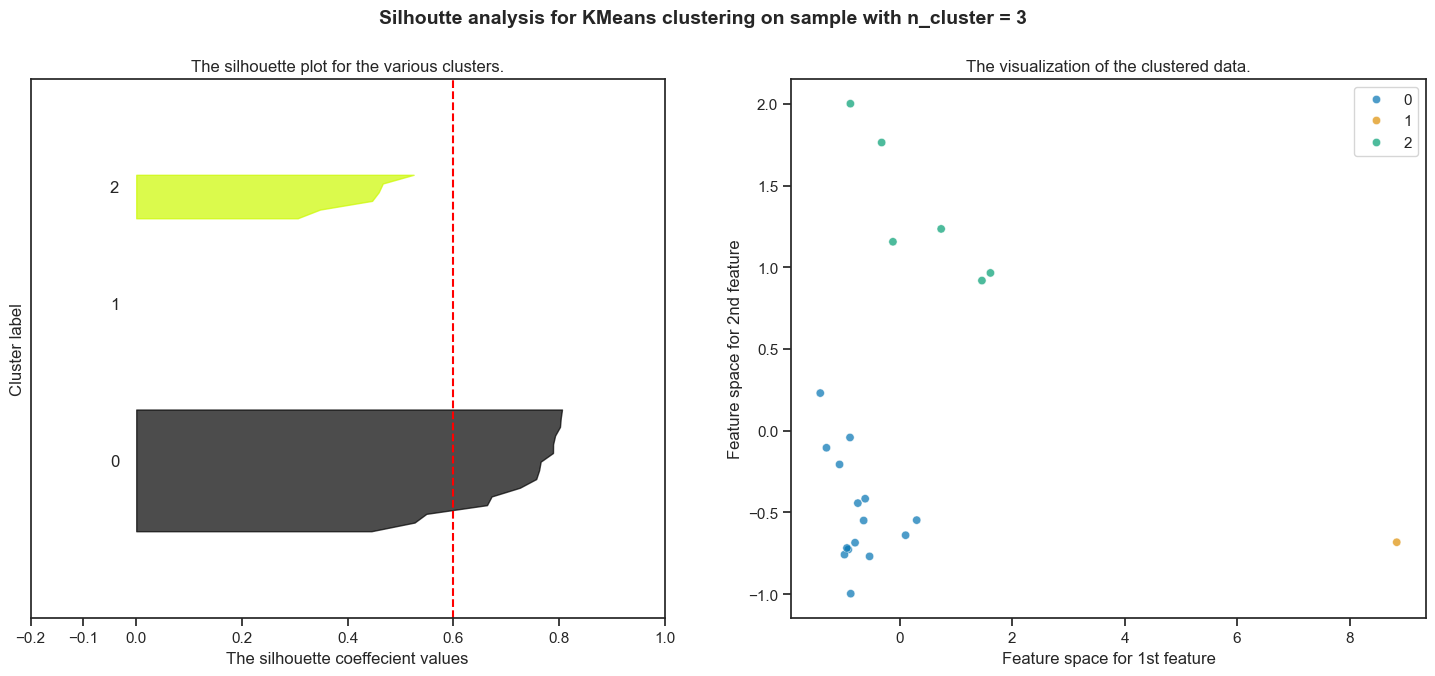

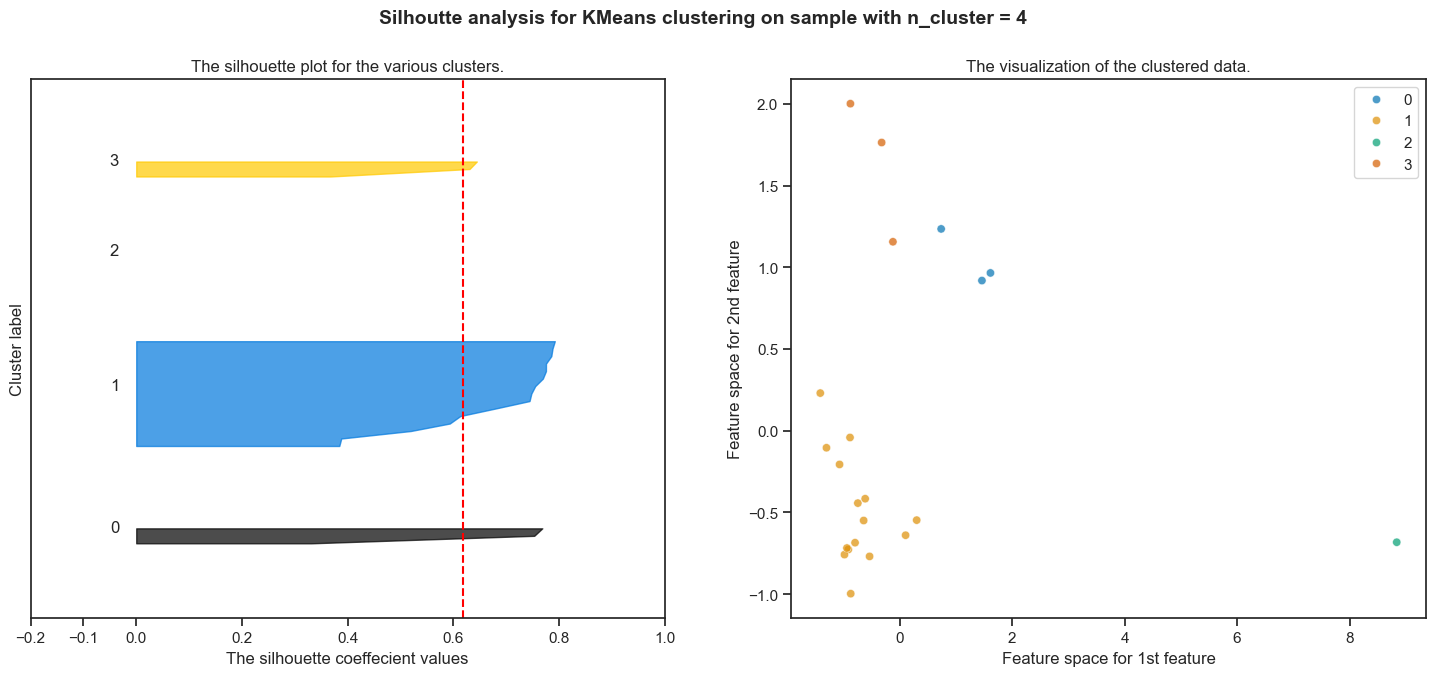

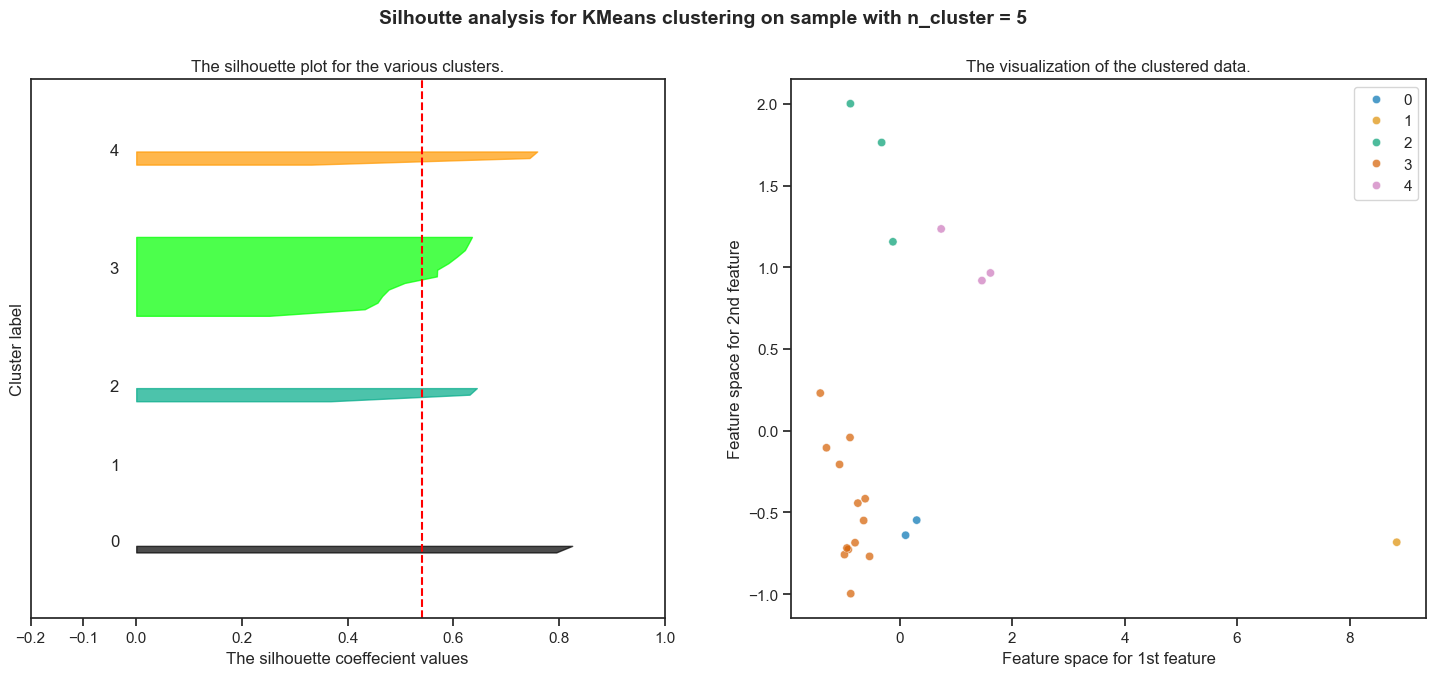

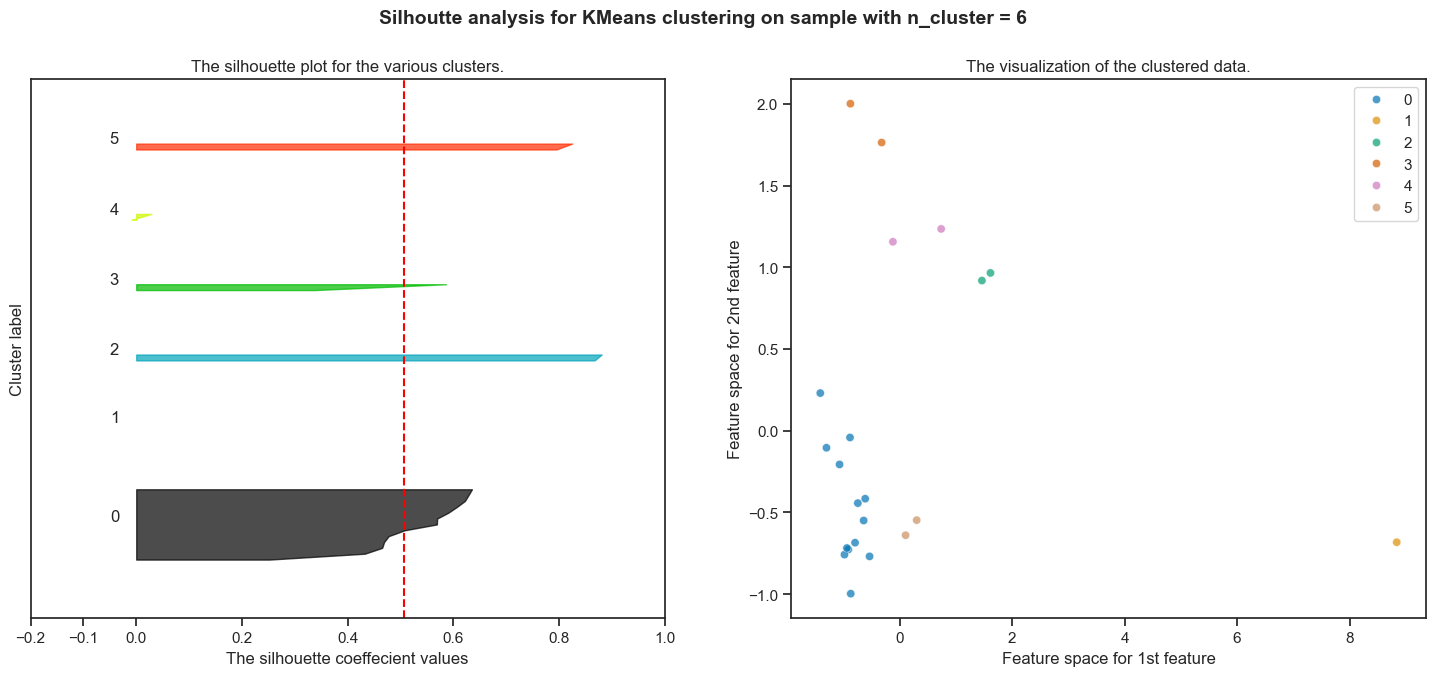

In [92]:
# we plot silhouette score for k means 
# here pcadf is the pca dataframe and Reduced is array of data after PCA 
sns.set_style('ticks') 
silhouette_plot(KMeans, range(3, 7), pcadf, reduced)

**Conclusion** 
* Cluster of 3 has a good balance of inertia an silhouette score we can go with 3 clusters.

In [93]:
# fitting the model to reduced data 
model = KMeans(n_clusters=3).fit(pcadf) 
model_label = model.labels_
model_centers = model.cluster_centers_

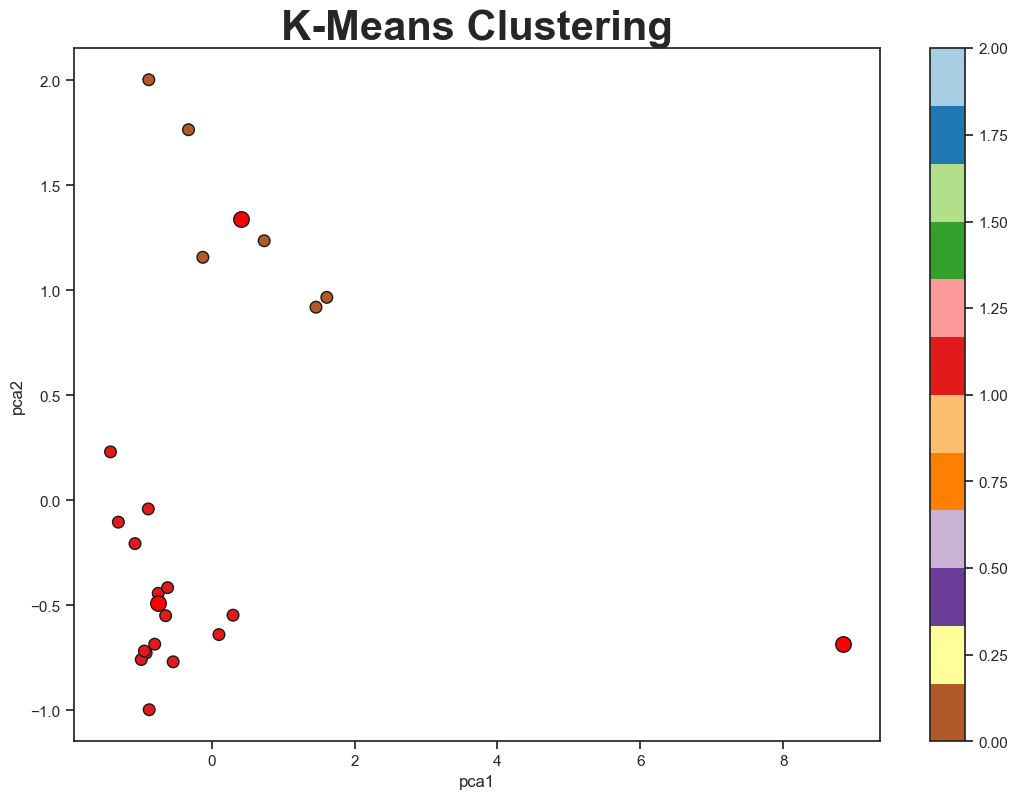

In [94]:
#Plotting the clusters
plt.figure(figsize=(13,9))
plt.title('K-Means Clustering', weight='bold', size=30)
plt.xlabel('pca1')
plt.ylabel('pca2')
scatter = plt.scatter(pcadf['PC1'], pcadf['PC2'], c=model_label, s=70, cmap='Paired_r', ec='k')
plt.colorbar(scatter)
plt.scatter(model_centers[:,0], model_centers[:,1], c='red', marker='.',s=500, ec='k');

---

### Hierarchical Clustering (Agglomerative)

* Agglomerative Clustering : Also known as bottom-up approach or hierarchical agglomerative clustering(HAC).
* A structure that is more informative than the unstructured set of clusters returned by flat clustering. This clustering algorithm does not require us to prespecify the number of clusters. 
* Bottom-up algorithms treat each data as singleton cluster at the outset and then successively agglomerates pairs of clusters until all clusters have been merged into a single cluster that contain all data.

#### Silhouette Score Plot for Agglomerative Clustering to choose best number of clusters 

* We will go with the n_clusters range of 3-7 to find the best cluster for agglomerative clustering.

For n_clusters - 3 The average silhouette_score is 0.599964177398996
For n_clusters - 4 The average silhouette_score is 0.6067691242626542
For n_clusters - 5 The average silhouette_score is 0.524691240606108
For n_clusters - 6 The average silhouette_score is 0.533544977645777
For n_clusters - 7 The average silhouette_score is 0.520918456126967


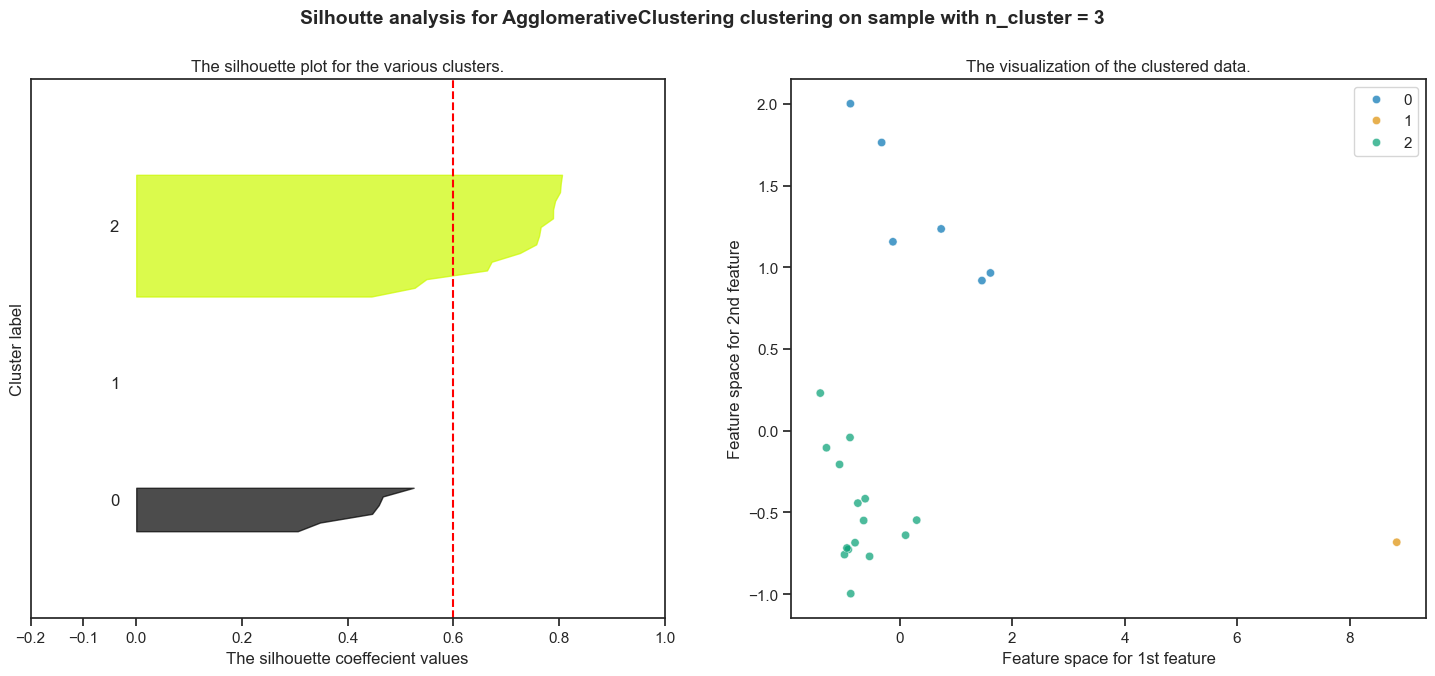

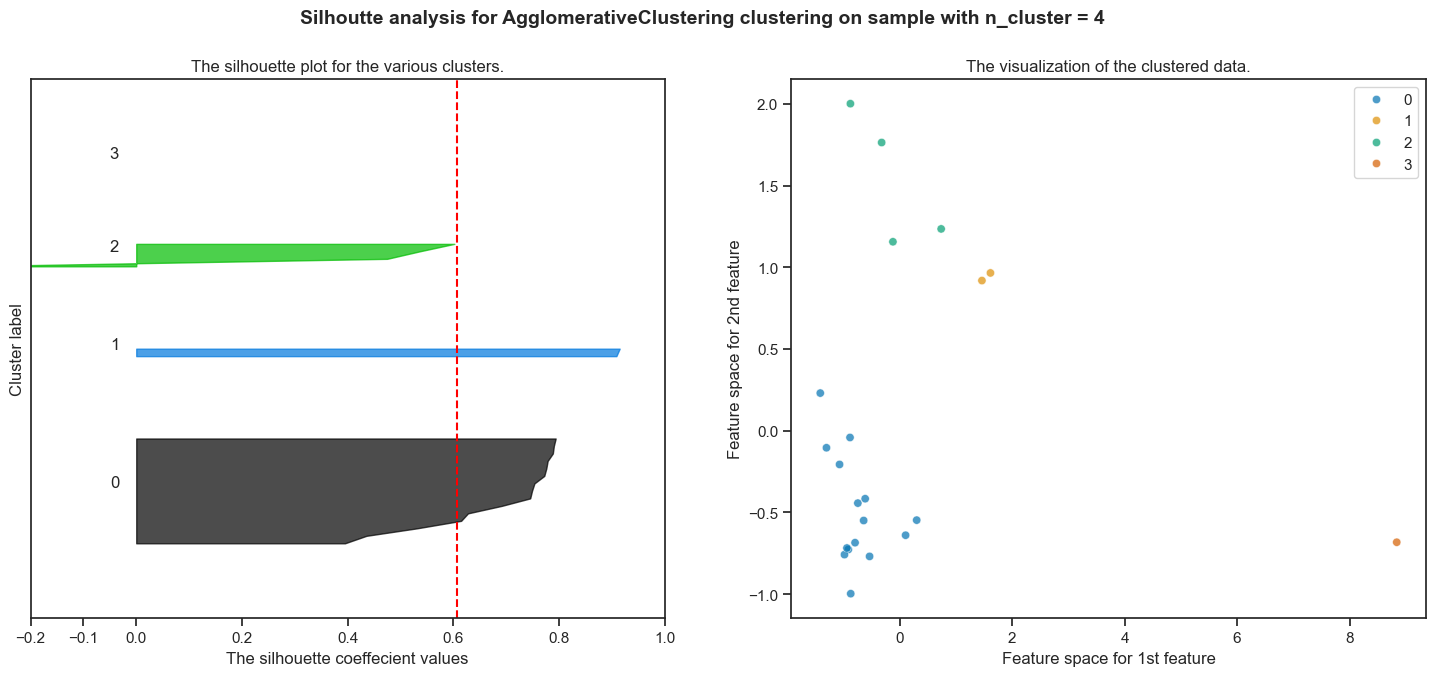

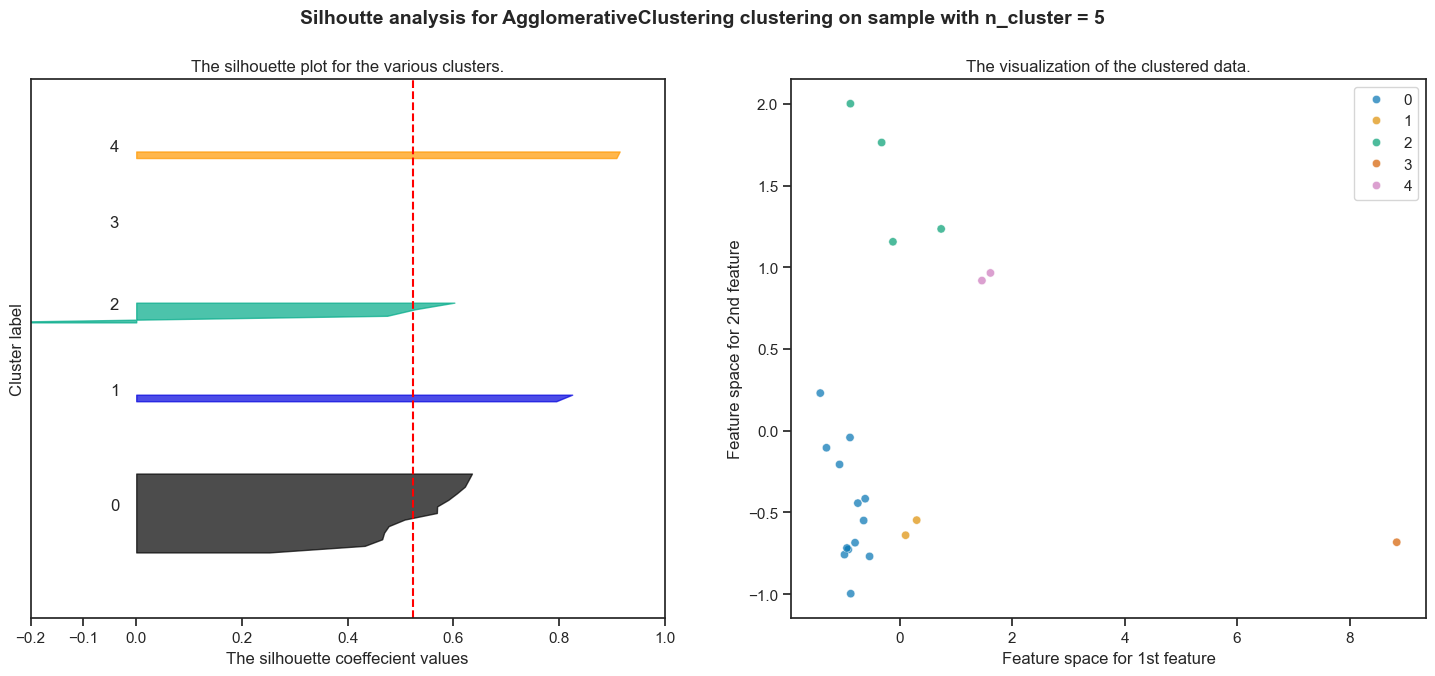

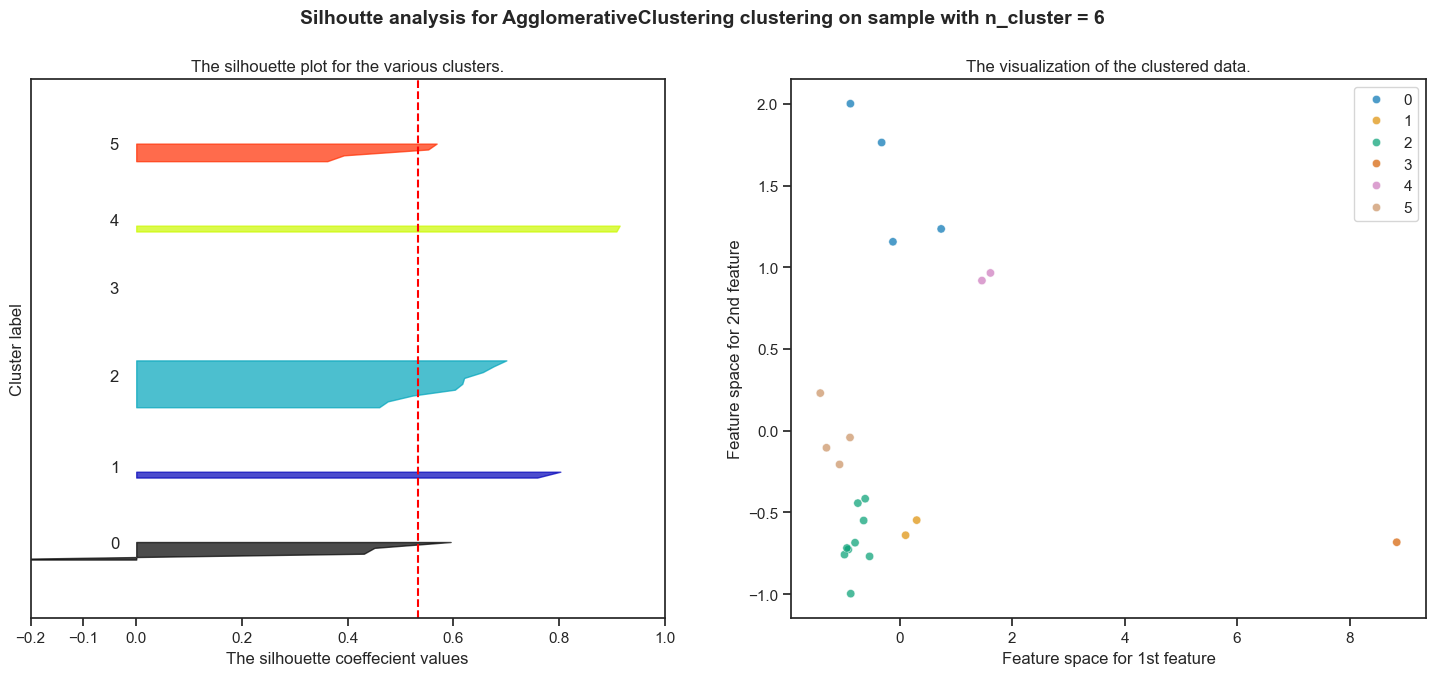

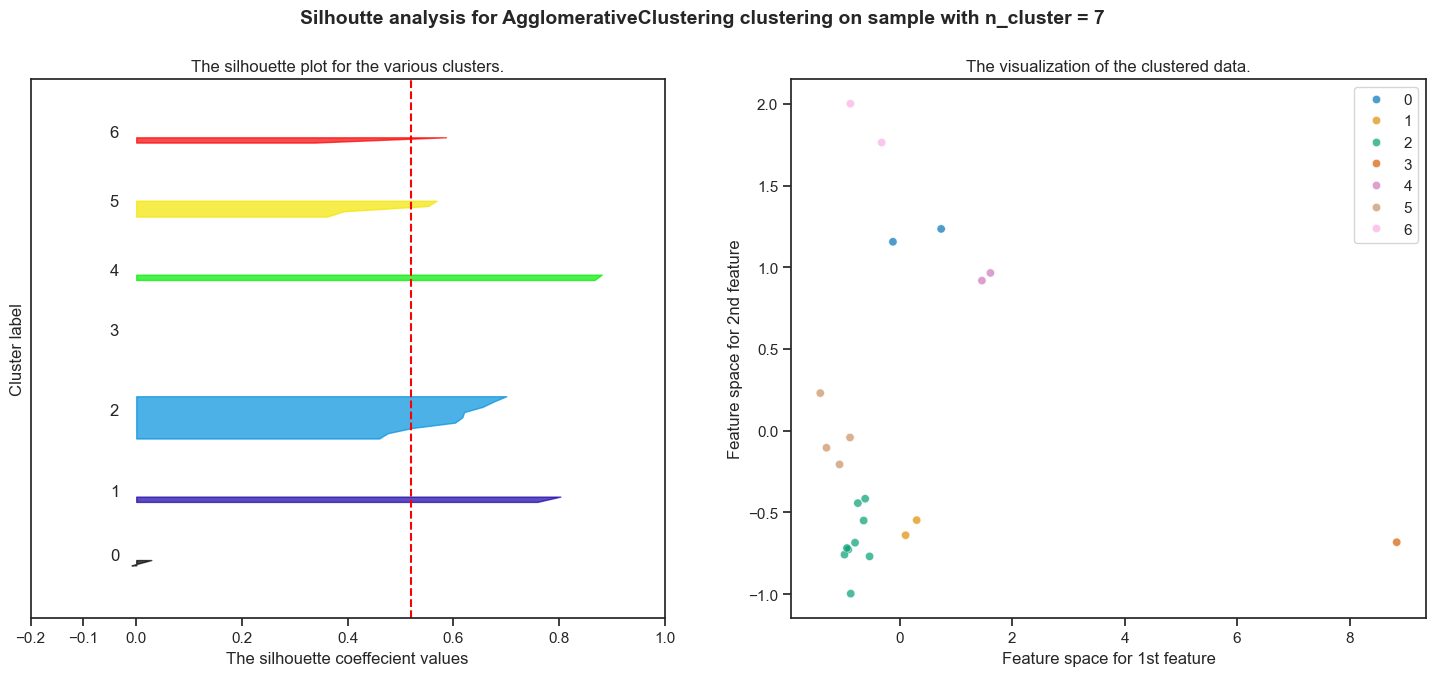

In [95]:
#Plot Score to choose best clusters
silhouette_plot(AgglomerativeClustering,range(3,8),pcadf,reduced)

**Conclusions:**
* In this case also we have a good balance of Inertia and silhouette score, we can go with 3 clusters.

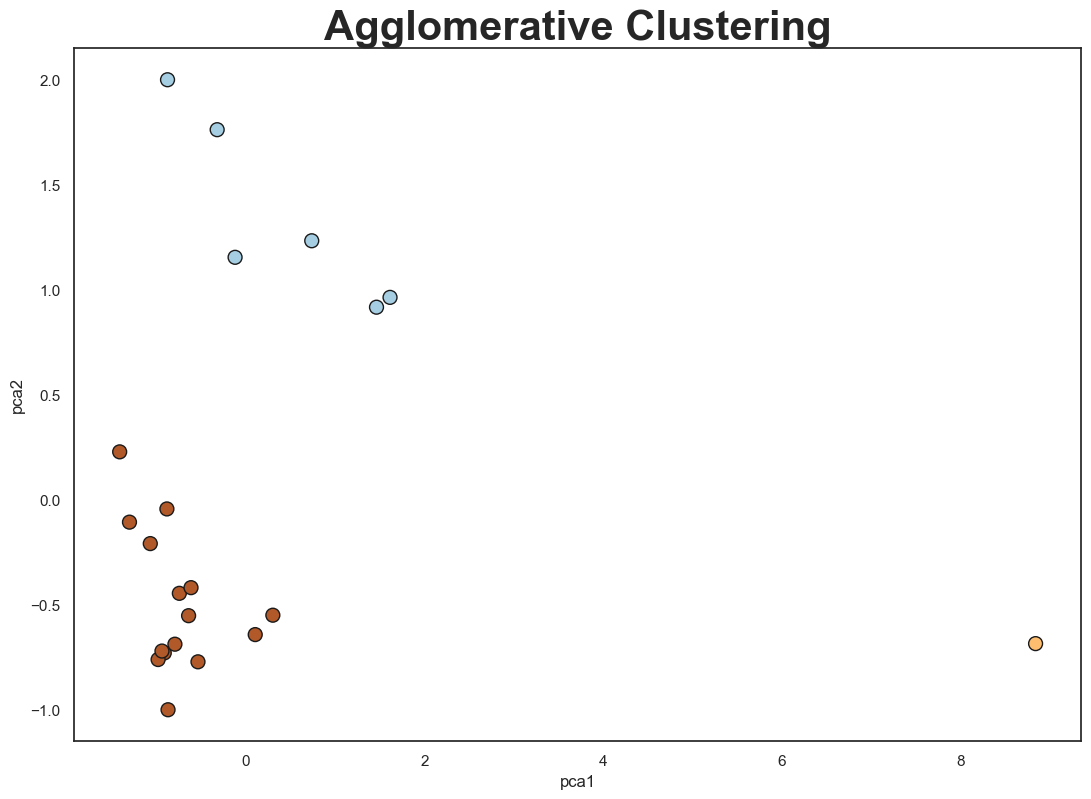

In [96]:
model = AgglomerativeClustering(n_clusters=3,metric='euclidean', linkage='ward').fit(reduced)
model_label = model.labels_
plt.figure(figsize=(13,9))

sns.set_style('white')
plt.title('Agglomerative Clustering', weight='bold', size=30)
plt.xlabel('pca1')
plt.ylabel('pca2')
scatter = plt.scatter(pcadf['PC1'], pcadf['PC2'], c=model_label, s=100, cmap='Paired', ec='k')

**Report** 

* Agglomerative clustering performed similar to K-Means Clustering.
* The best silhouette score is 0.60 whereas for K means it had 0.59.

---

#### Gaussian Mixture

* A Gaussian mixture model is a probabilistic model that assumes all data points are generated from a mixture of a finite number of Gaussian distributions with unknown parameters. 
* One can think of mixture models as generalizing k-means clustering to incorporate information about the covariance structure of the data as well as the centers of the latent Gaussians .  

For n_clusters - 3 The average silhouette_score is 0.599964177398996
For n_clusters - 4 The average silhouette_score is 0.3861325360751614
For n_clusters - 5 The average silhouette_score is 0.5413928324347854
For n_clusters - 6 The average silhouette_score is 0.2648072956642213
For n_clusters - 7 The average silhouette_score is 0.5161372903141229


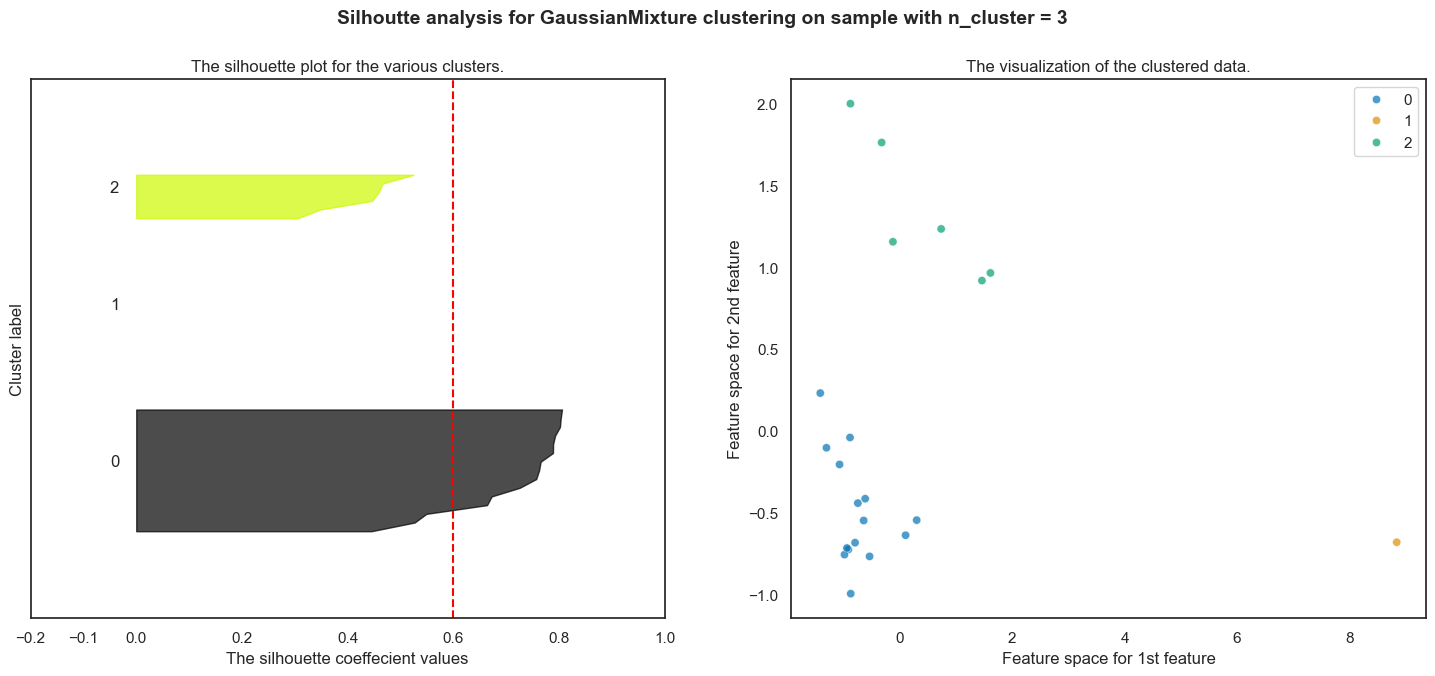

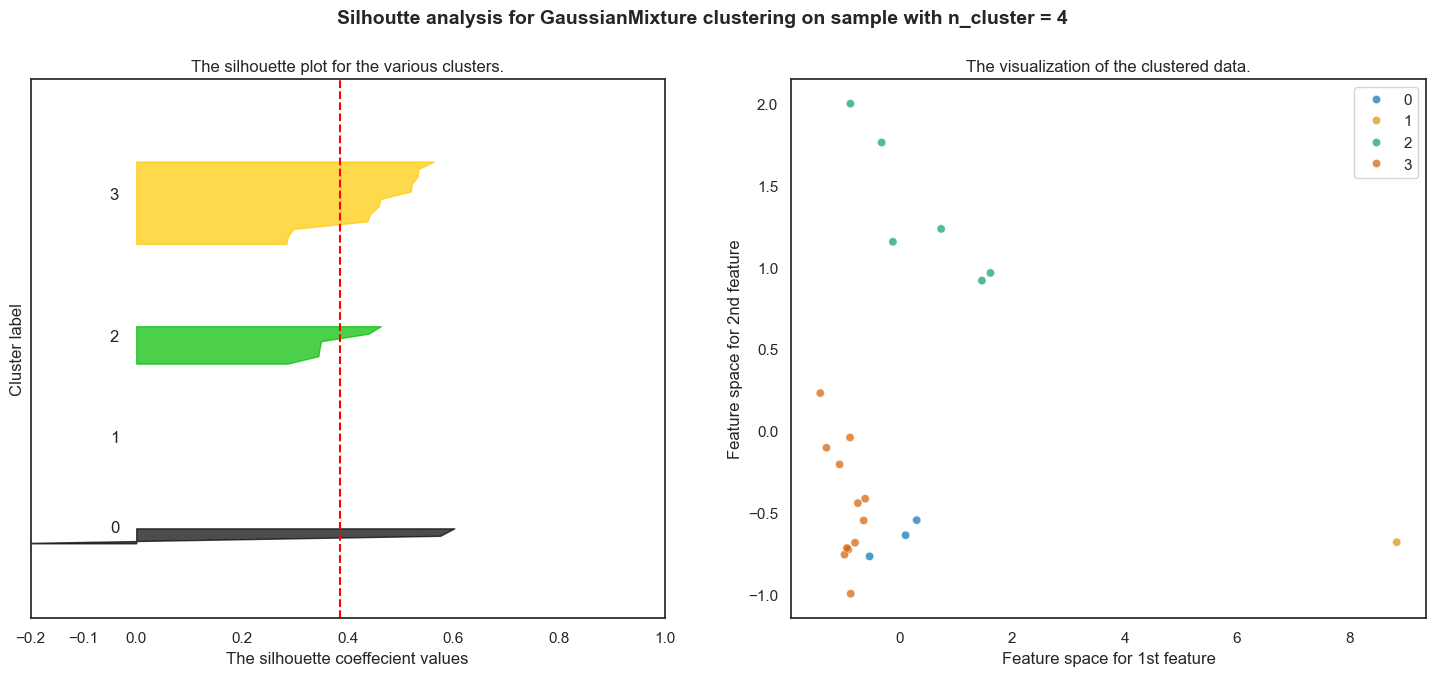

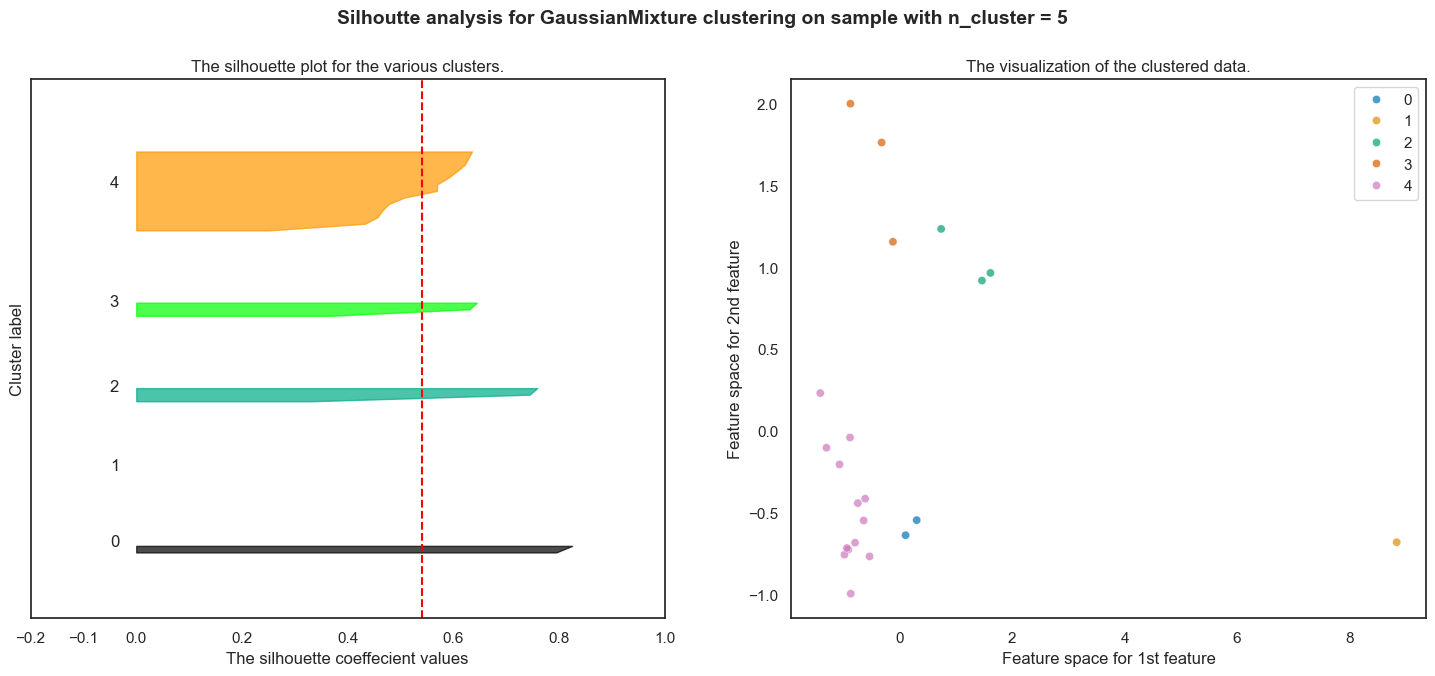

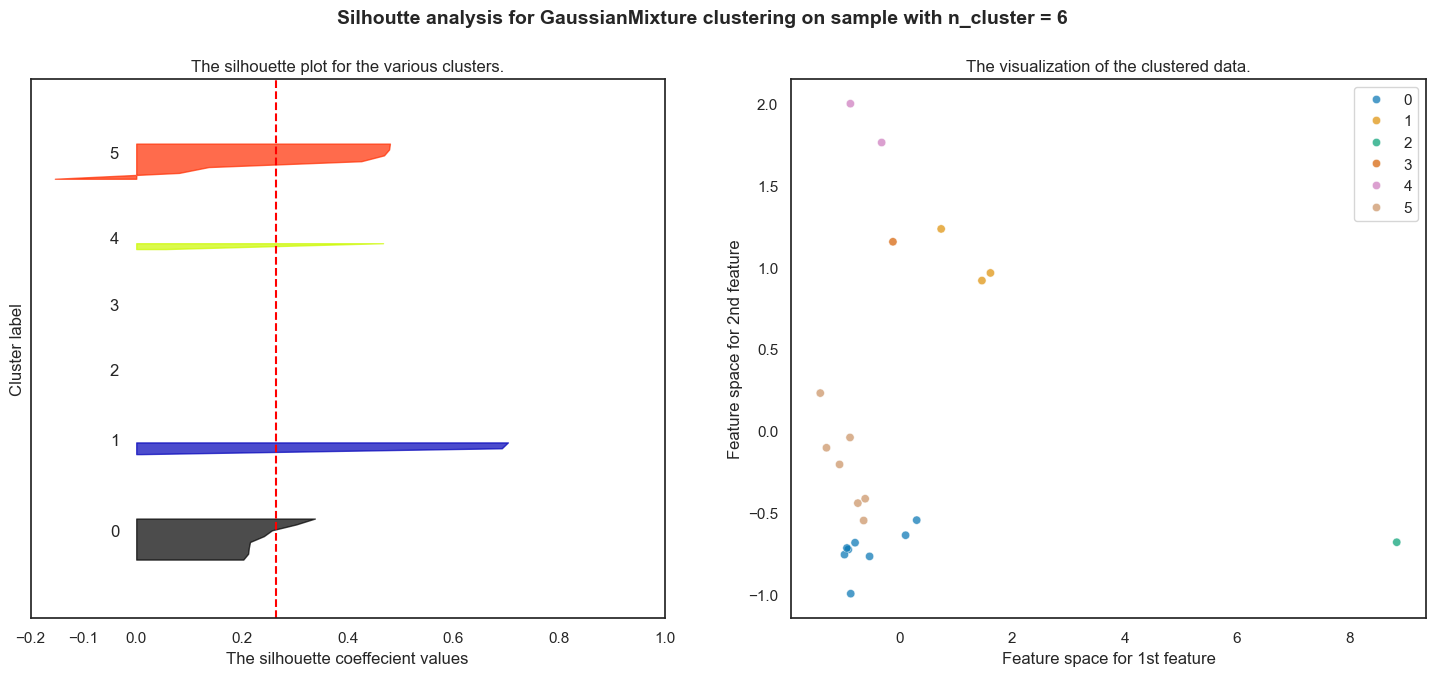

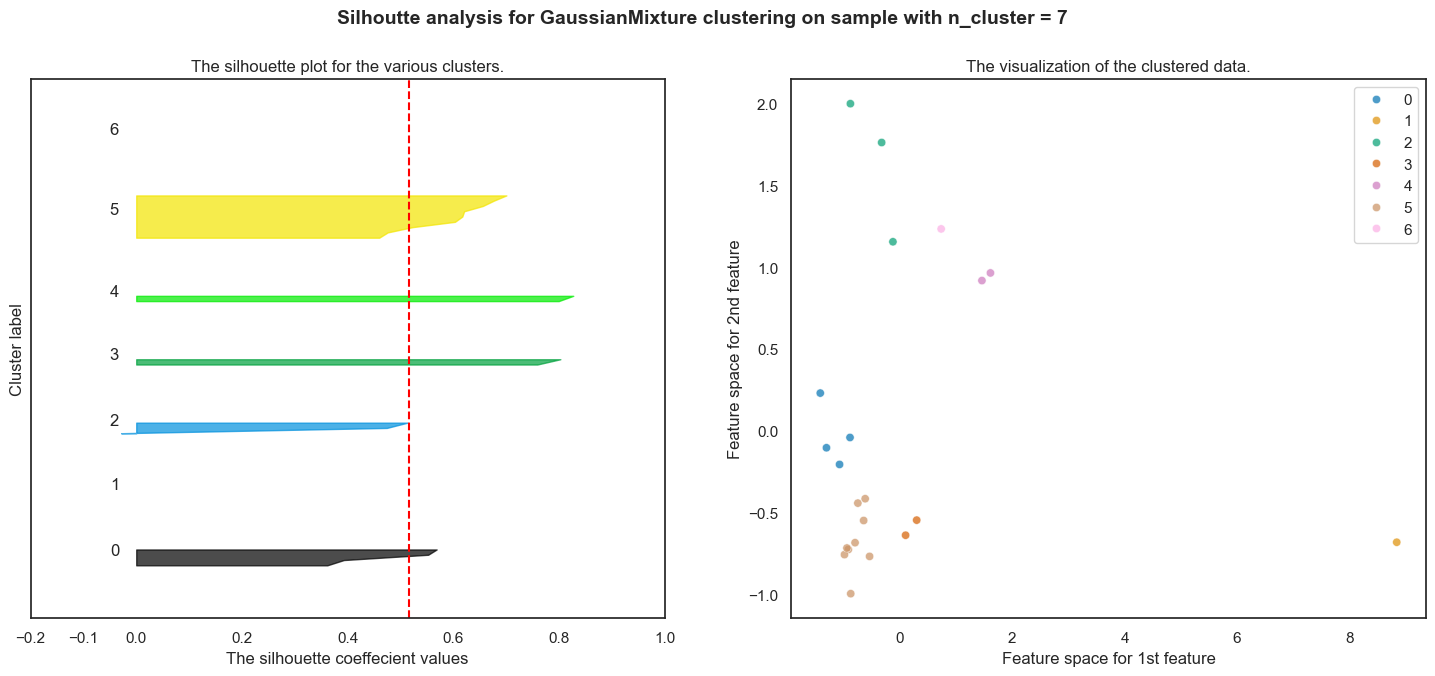

In [97]:
#plotting silhoutte score for Gaussian score
silhouette_plot(GaussianMixture,range(3,8),pcadf,reduced)

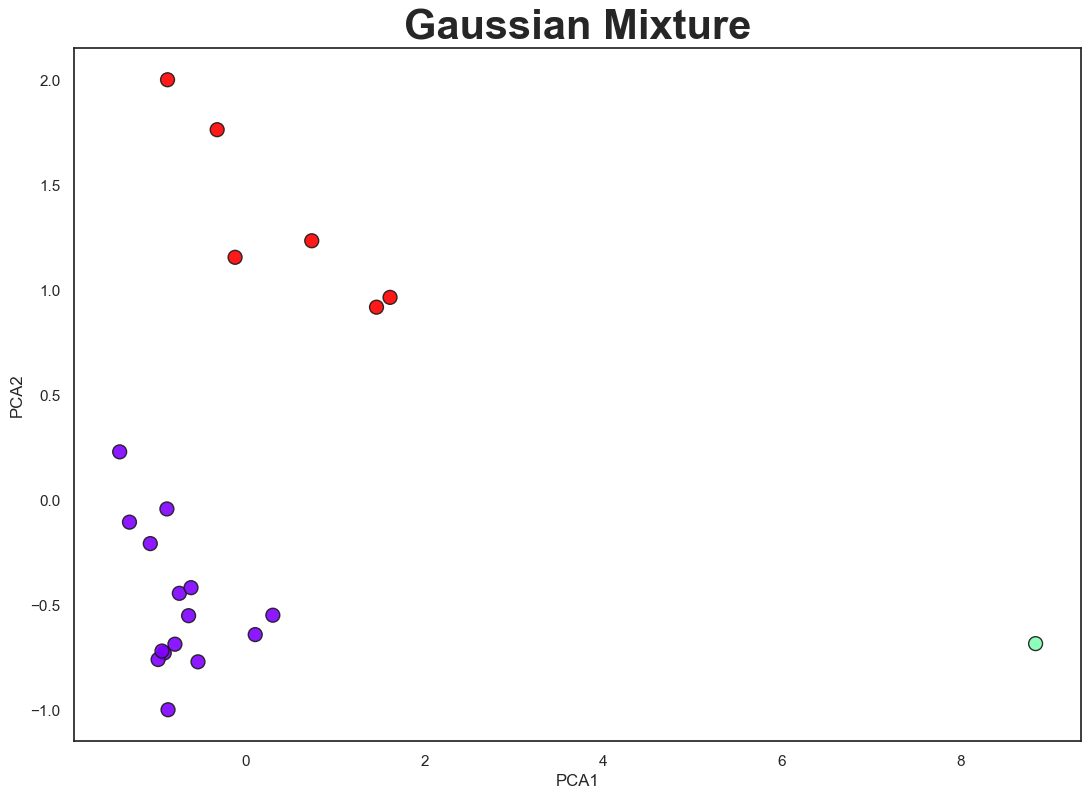

In [98]:
#plotting gaussian mixture with 4 clusters
model = GaussianMixture(n_components=3,random_state=42).fit(reduced)
model_label = model.predict(reduced)
plt.figure(figsize=(13,9))

sns.set_style('white')
plt.title('Gaussian Mixture', weight='bold', size=30)
plt.xlabel('PCA1')
plt.ylabel('PCA2')
scatter = plt.scatter(pcadf['PC1'], pcadf['PC2'], c=model_label, s=100, cmap='rainbow', ec='k', alpha=0.9)

---

#### DBSCAN Clustering

* Density-based spatial clustering of applications with noise(DBSCAN) is a data clustering algorithm.
* DBSCAN algorithm group points based on distance measurement, usually the Euclidean distance and the minimum number of points. An essential property of this algorithm is that it helps us track down the outliers as the points in low-density regions; hence it is not sensitive to outliers as is the case of K-Means clustering. 

**Minimum Points minPts** 

In DBSCAN minPts is the minimum number of data points that should be there in the region to define the cluster. We can choose the value of minPts based on our domain knowledge. But if we lack domain knowledge a good reference point is to have minPts >= D + 1  where D is the dimension of the dataset. 

It is recommended to keep the value for the minPts at least 3, but for larger data sets, a greater minPts value should be chosen, especially if it has many outliers. 

##### Finding the Optimal value of Epsilon

Rather than experimenting with different values of epsilon, we can use the elbow point detection method to arrive at a suitable epsilon.

In this approach, the average distance between each point and its k nearest neighbors is calculated where k = the MinPts selected.

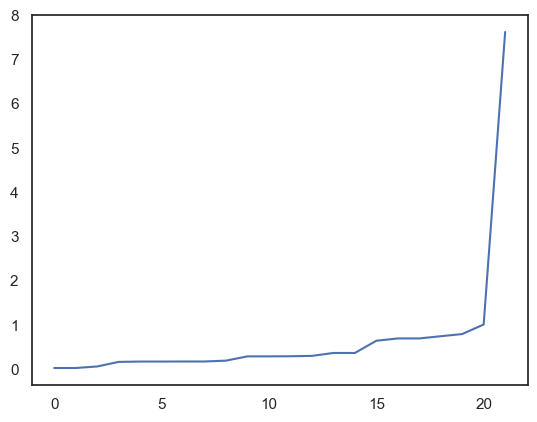

In [99]:
neighbors = NearestNeighbors(n_neighbors=17)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

distances = np.sort(distances, axis=0)

distances = distances[:,1]
plt.plot(distances)
plt.show()

#### **Kneedle Algorithm**

* The Kneedle algorithm here via Kevin Arvai's excellent python implementation called Kneed. We can download this via PyPi .

<Figure size 500x500 with 0 Axes>

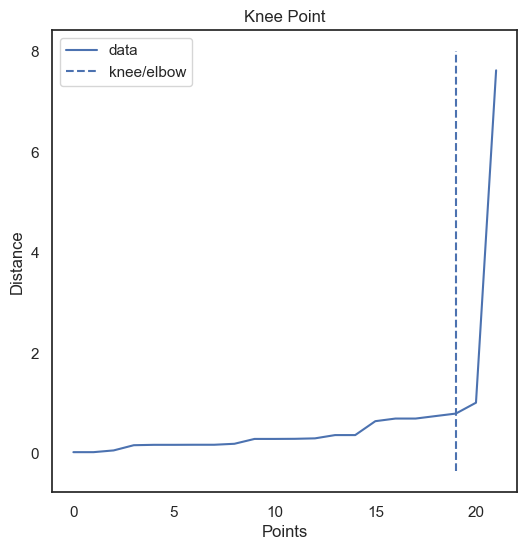

Knee Locator k = 0.7963314832147684


In [100]:
i = np.arange(len(distances))
knee = KneeLocator(i, distances, S=1, curve='convex', direction='increasing', interp_method='polynomial')

fig = plt.figure(figsize=(5, 5))
knee.plot_knee()
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()
k= distances[knee.knee]
print('Knee Locator k =', k)

#### For 2 Dimensional data, we will uses DBSCAN's default value of MinPts = 4

**DBSCAN algorithm works with two parameters** 

These parameters are: 

* Epsilon (Eps): This is the least distance required for two points to be termed as neighbor. This distance is known as Epsilon. Thus we consider Eps as threshold for considering two points as neighbor.

* MinPoints : This refers to the minimum number of points needed to construct a cluster. We consider MinPoints as a threshold for considering a cluster as a cluster. A cluster is only recognized if the number of points is greater than or equal to MinPts.

###### Plotting Using PCA

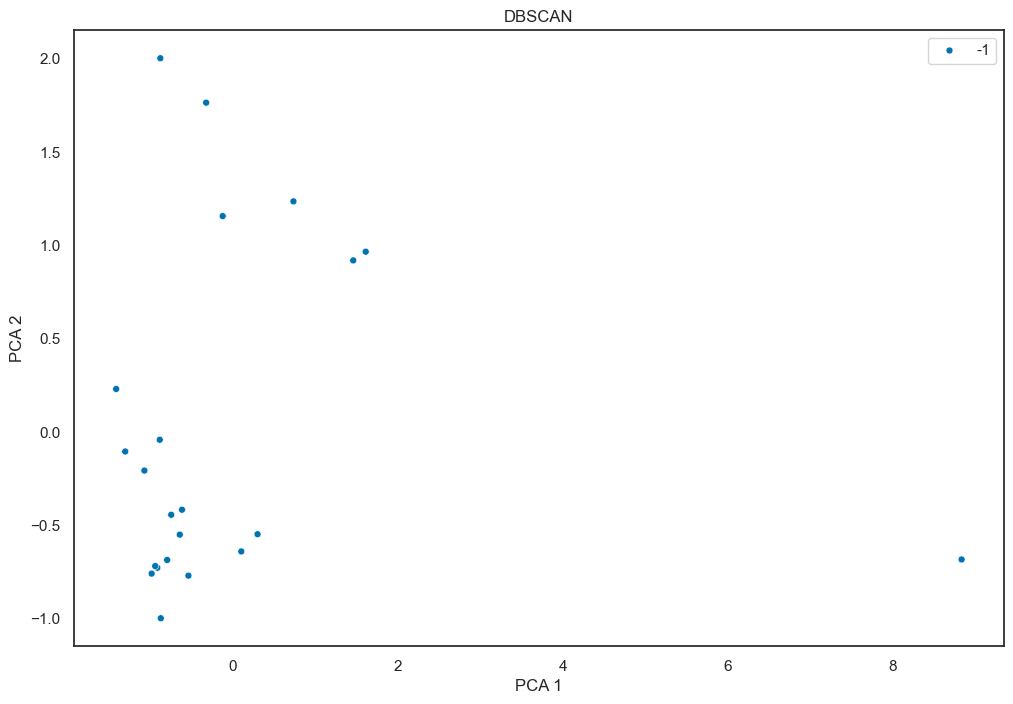

In [101]:
model=DBSCAN(eps=k , min_samples=100).fit(df_scaled)
model_label = model.labels_
plt.figure(figsize=(12,8))

plt.title('DBSCAN')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
scatter = sns.scatterplot(x = reduced[:,0], y = reduced[:,1], hue= model_label,
                      palette=sns.color_palette("colorblind", len(set(model_label))), s=25)

#### DBSCAN didn't perform well

* It is clear that DBSCAN does not work well when we are dealing with clusters of varying densities or with high dimensional data.

---

##### Final Model 

As K Means performed similar to other algorithms we are going with K-Means Clustering. 

In [102]:
cluster_profile = transformer_features.copy()
model = KMeans(n_clusters=3).fit(pcadf) 
counts = Counter(model.labels_)
print(counts)
labels= model.labels_
cluster_profile["cluster"] = labels

Counter({0: 15, 2: 6, 1: 1})


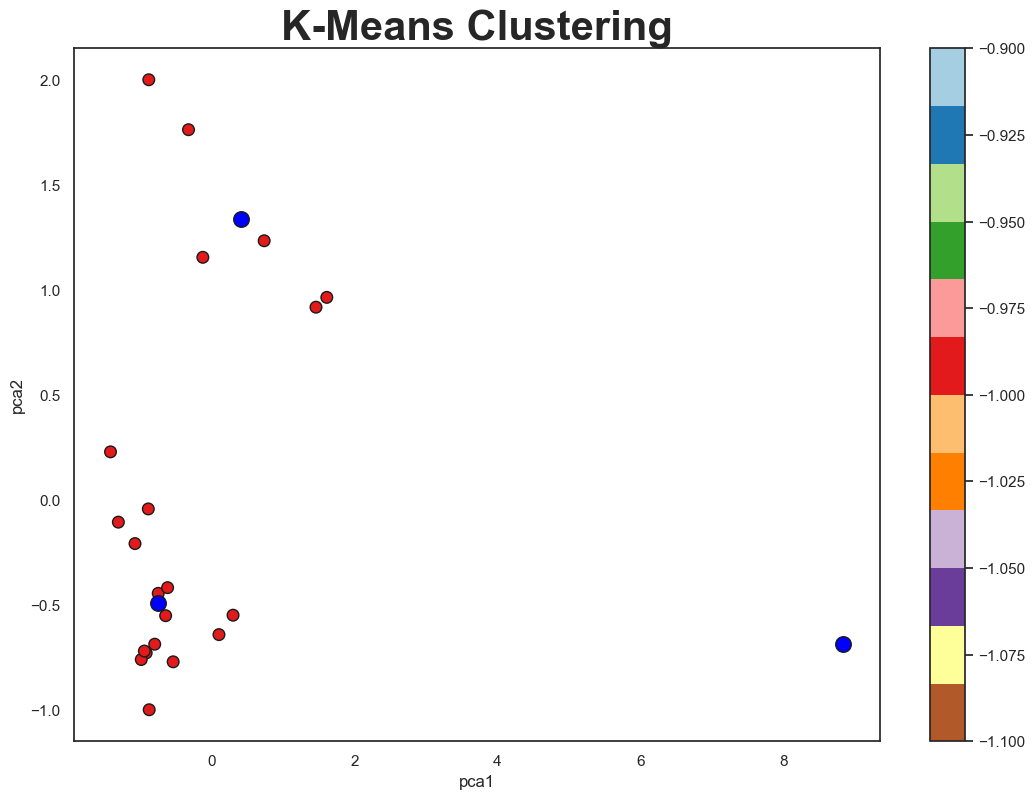

In [103]:
#Plotting the clusters
plt.figure(figsize=(13,9))
plt.title('K-Means Clustering', weight='bold', size=30)
plt.xlabel('pca1')
plt.ylabel('pca2')
scatter = plt.scatter(pcadf['PC1'], pcadf['PC2'], c=model_label, s=70, cmap='Paired_r', ec='k')
plt.colorbar(scatter)
plt.scatter(model_centers[:,0], model_centers[:,1], c='blue', marker='.',s=500, ec='k');

---

#### Saving the data with cluster column

---

In [104]:
cluster_profile

,zone,total_energy,peak_load,avg_load,load_factor,range,cv,peak_to_avg_ratio,max_peak,cluster
0,AE,2.702048e+04,1345.003793,563.230114,0.422971,1281.087578,0.242880,2.388018,2549.433,2
1,AEP,3.552039e+05,7681.410973,3702.373842,0.485814,7134.248473,0.129878,2.074726,11968.516,2
2,AP,1.339912e+05,6445.359307,5586.492955,0.869573,1707.045111,0.141006,1.153740,9791.610,0
3,ATSI,1.808215e+05,7985.183487,3769.107496,0.474672,7529.823148,0.126034,2.118587,11876.748,2
4,BC,8.367460e+04,4197.929761,3488.705137,0.835991,1360.664982,0.176720,1.203292,6765.920,0
5,CE,2.572276e+05,12524.535419,10723.237930,0.863857,3636.395534,0.157685,1.167981,22467.007,0
6,DAY,4.721995e+04,2290.095944,1968.591748,0.864065,667.910800,0.145250,1.163317,3396.336,0
7,DEOK,7.182934e+04,3500.705075,2994.614661,0.861512,1039.965771,0.150303,1.169000,5305.660,0
8,DOM,3.190139e+05,15526.363338,13301.796705,0.859979,4295.380541,0.171965,1.167238,24678.126,0
9,DPL,5.084664e+04,2547.384533,1060.034159,0.418844,2524.779823,0.196974,2.403116,4139.729,2


In [105]:
segment_map = {
    0: "Commercial",
    1: "Industrial",
    2: "Residential"
}

transformer_features['segment'] = cluster_profile['cluster'].map(segment_map)

In [106]:
transformer_features.to_csv('Preprocessed.csv')

In [107]:
Residential_Zone = transformer_features[transformer_features['segment'] == 'Residential']['zone'].values.tolist()

In [108]:
Commercial_Zone = transformer_features[transformer_features['segment'] == 'Commercial']['zone'].values.tolist()

In [109]:
Industrial_Zone = transformer_features[transformer_features['segment'] == 'Industrial']['zone'].values.tolist()

In [110]:
mask=daily['zone'].isin(Residential_Zone)
daily_residential = daily[mask]

In [111]:
daily_residential.reset_index(drop=True,inplace=True)
daily_residential.to_csv("daily_residential.csv")
daily_residential

,zone,date,total_energy,peak_load,avg_load,min_load,load_factor,utilization_rate,range,cv
0,AE,2020-02-01,18895.503,1090.572,497.250079,60.255,0.455953,0.427770,1030.317,0.242880
1,AE,2020-02-02,23937.270,1125.985,498.693125,50.009,0.442895,0.441661,1075.976,0.242880
2,AE,2020-02-03,23289.581,1100.489,485.199604,55.602,0.440895,0.431660,1044.887,0.242880
3,AE,2020-02-04,23833.218,1096.465,496.525375,60.844,0.452842,0.430082,1035.621,0.242880
4,AE,2020-02-05,24308.232,1158.962,506.421500,58.605,0.436961,0.454596,1100.357,0.242880
...,...,...,...,...,...,...,...,...,...,...
13153,PL,2026-01-28,162402.086,7156.150,3383.376792,165.482,0.472793,0.912806,6990.668,0.142386
13154,PL,2026-01-29,165636.349,7338.675,3450.757271,170.031,0.470215,0.936088,7168.644,0.142386
13155,PL,2026-01-30,167289.999,7409.952,3485.208313,165.851,0.470342,0.945180,7244.101,0.142386
13156,PL,2026-01-31,162426.184,7099.635,3383.878833,164.903,0.476627,0.905597,6934.732,0.142386


In [112]:
mask=daily['zone'].isin(Commercial_Zone)
daily_commercial = daily[mask]
daily_commercial.reset_index(inplace=True)
daily_commercial.drop("index",axis=1,inplace=True)
daily_commercial.to_csv("daily_commercial.csv")

In [113]:
daily_Industrial = daily[daily['zone'] == "RTO"]

In [114]:
daily_Industrial.reset_index(drop=True,inplace=True)
daily_Industrial.to_csv("daily_Industrial.csv")

In [115]:
zones = df_old['zone'].unique().tolist()

In [116]:
file_path = "Residential_data/"
for z in Residential_Zone:
    data = df_old[df_old['zone']==z]
    data.to_csv(file_path +  "Data_Residential_"+z+".csv", index=False)

In [117]:
file_path = "Commercial_data/"
for z in Commercial_Zone:
    data = df_old[df_old['zone']==z]
    data.to_csv(file_path +  "Data_Commercial_"+z+".csv", index=False)

In [118]:
file_path = "Industrial_data/"
for z in Industrial_Zone:
    data = df_old[df_old['zone']==z]
    data.to_csv(file_path +  "Data_Industrial_"+z+".csv", index=False)

---

#### Final Report 

* As we got the EDA Results, we used that ame approaches here also. We extracted out some features to derive valuable meanings from the data and used those in model training. 
* The data was of higher scale, so we normalized it to bring it to standard scale, For that purpose we used RobustScaler instead of StandardScaler. 
* We have used PCA to minimize the data. 
* All the clustering performed equally on the dataset so we choose the KMeans Clustering as it was mentioned in the Paper.

---